In [5]:
import pandas as pd
import numpy as np
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [6]:
df = pd.read_csv('C:/Users/hp/Downloads/indian_startup_funding_2020_2025_sample.csv')
print(df.shape)
print(df.head())

(1100, 8)
    Startup              Industry   SubVertical       City  \
0  Housejoy                EdTech           K12     Mumbai   
1     Groww                 Media     Streaming  Bengaluru   
2     Groww              Mobility  Ride Sharing  Hyderabad   
3   FarmBox  Consumer Electronics     Wearables   Gurugram   
4     Udaan            RealEstate   Rental Tech     Mumbai   

                         Investors InvestmentType  InvestmentAmount_USD  \
0                 Lightspeed India           Seed                199000   
1                              IFC           Seed               1668000   
2  Nexus Venture Partners, Peak XV       Series B              38052000   
3    Kalaari Capital, Y Combinator           Seed                455000   
4        Bessemer Venture Partners           Seed                 89000   

         Date  
0  19-04-2023  
1  28-01-2025  
2  14-03-2021  
3  11-09-2023  
4  31-01-2024  


In [7]:
print(df['Industry'].value_counts())

Industry
E-commerce              90
Retail                  89
Consumer Electronics    87
Mobility                86
Media                   85
AgriTech                82
FoodTech                80
RealEstate              79
EdTech                  78
HealthTech              76
FinTech                 73
SaaS                    72
Enterprise              66
Logistics               57
Name: count, dtype: int64


In [8]:
print(df['City'].value_counts())

City
Delhi        128
Kolkata      116
Pune         113
Chennai      112
Ahmedabad    111
Gurugram     109
Bengaluru    107
Mumbai       104
Noida        104
Hyderabad     96
Name: count, dtype: int64


In [9]:
print(df['InvestmentType'].value_counts())

InvestmentType
Seed              353
Series A          227
Series B          110
Series C           95
Pre-Series A       88
Angel              62
Pre-Seed           51
Bridge             39
Growth             25
Series D           24
Debt               21
Private Equity      5
Name: count, dtype: int64


In [10]:
import os
print(os.getcwd())

C:\Users\hp\Trikala_Darshana\data


In [11]:
import os
os.chdir('C:/Users/hp/Trikala_Darshana')
print(os.getcwd())

C:\Users\hp\Trikala_Darshana


In [12]:
import pandas as pd
import numpy as np

# Load both datasets — no 'data/' needed since we're already in data folder!
df1 = pd.read_csv('C:/Users/hp/Trikala_Darshana/data/indian_startup_funding_2020_2025_sample.csv')
df2 = pd.read_csv('C:/Users/hp/Trikala_Darshana/data/big_startup_secsees_dataset.csv')

print("Indian Dataset:", df1.shape)
print("Global Dataset:", df2.shape)

Indian Dataset: (1100, 8)
Global Dataset: (66368, 14)


In [13]:
# Filter Indian startups
df2_india = df2[df2['country_code'] == 'IND']

# Clean columns
df2_india_clean = df2_india[[
    'name', 'category_list', 'funding_total_usd',
    'status', 'country_code', 'city',
    'funding_rounds', 'founded_at',
    'first_funding_at', 'last_funding_at'
]].copy()

df2_india_clean.columns = [
    'Startup', 'Industry', 'TotalFunding',
    'Status', 'Country', 'City',
    'FundingRounds', 'FoundedAt',
    'FirstFundingAt', 'LastFundingAt'
]

# Convert Status to numbers
status_mapping = {
    'operating': 0,
    'closed': 1,
    'acquired': 2,
    'ipo': 2
}

df2_india_clean['StatusCode'] = df2_india_clean['Status'].map(status_mapping)

print("Status distribution:")
print(df2_india_clean['StatusCode'].value_counts())

Status distribution:
StatusCode
0    1467
1      69
2      60
Name: count, dtype: int64


In [14]:
# Save cleaned Indian dataset
df2_india_clean.to_csv('trikala_india_clean.csv', index=False)
print("Dataset saved successfully!")
print("Total Indian startups:", len(df2_india_clean))
print("Failed startups:", len(df2_india_clean[df2_india_clean['StatusCode']==1]))
print("Active startups:", len(df2_india_clean[df2_india_clean['StatusCode']==0]))

Dataset saved successfully!
Total Indian startups: 1596
Failed startups: 69
Active startups: 1467


In [15]:
# Prepare features for ML model
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Select features
features_df = df2_india_clean.copy()

# Convert TotalFunding to numeric
features_df['TotalFunding'] = pd.to_numeric(
    features_df['TotalFunding'], errors='coerce'
).fillna(0)

# Convert FundingRounds to numeric
features_df['FundingRounds'] = pd.to_numeric(
    features_df['FundingRounds'], errors='coerce'
).fillna(0)

# Encode City
le_city = LabelEncoder()
features_df['CityEncoded'] = le_city.fit_transform(
    features_df['City'].fillna('Unknown')
)

# Encode Industry
le_industry = LabelEncoder()
features_df['IndustryEncoded'] = le_industry.fit_transform(
    features_df['Industry'].fillna('Unknown')
)

print("Features prepared!")
print(features_df[['Startup', 'TotalFunding', 'FundingRounds', 
                    'CityEncoded', 'IndustryEncoded', 'StatusCode']].head())

Features prepared!
           Startup  TotalFunding  FundingRounds  CityEncoded  IndustryEncoded  \
0            #fame    10000000.0              1           61              719   
22       1000Lookz           0.0              1           18              155   
93          1CLICK           0.0              1            6              214   
135     21Diamonds     6369507.0              1           33              394   
151  24x7 Learning     4000000.0              1            6              466   

     StatusCode  
0             0  
22            0  
93            2  
135           0  
151           0  


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Select features and target
X = features_df[['TotalFunding', 'FundingRounds', 
                  'CityEncoded', 'IndustryEncoded']]
y = features_df['StatusCode']

# Split data — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Training samples: 1276
Testing samples: 320

Model Accuracy: 91.56 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       298
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00         9

    accuracy                           0.92       320
   macro avg       0.31      0.33      0.32       320
weighted avg       0.87      0.92      0.89       320



In [17]:
from sklearn.utils import class_weight
import numpy as np

# Fix class imbalance
model_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print("Balanced Model Accuracy:", round(accuracy_balanced * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Accuracy: 91.88 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       298
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00         9

    accuracy                           0.92       320
   macro avg       0.31      0.33      0.32       320
weighted avg       0.87      0.92      0.89       320



In [18]:
!pip install imbalanced-learn

In [19]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())

# Train new balanced model
model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_smote.fit(X_resampled, y_resampled)

# Test
y_pred_smote = model_smote.predict(X_test)
print("\nSMOTE Model Accuracy:", 
      round(accuracy_score(y_test, y_pred_smote) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_smote))

ImportError: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())

# Train new balanced model
model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_smote.fit(X_resampled, y_resampled)

# Test
y_pred_smote = model_smote.predict(X_test)
print("\nSMOTE Model Accuracy:", 
      round(accuracy_score(y_test, y_pred_smote) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_smote))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample

# Separate majority and minority classes
X_train_df = X_train.copy()
X_train_df['StatusCode'] = y_train.values

majority = X_train_df[X_train_df['StatusCode'] == 0]
minority = X_train_df[X_train_df['StatusCode'] == 1]
minority2 = X_train_df[X_train_df['StatusCode'] == 2]

# Upsample minority classes
minority_upsampled = resample(minority, 
    replace=True,
    n_samples=len(majority),
    random_state=42)

minority2_upsampled = resample(minority2,
    replace=True,
    n_samples=len(majority),
    random_state=42)

# Combine
upsampled = pd.concat([majority, minority_upsampled, minority2_upsampled])

X_train_new = upsampled[['TotalFunding', 'FundingRounds', 
                          'CityEncoded', 'IndustryEncoded']]
y_train_new = upsampled['StatusCode']

print("New training distribution:")
print(y_train_new.value_counts())

# Train model
model_new = RandomForestClassifier(n_estimators=100, random_state=42)
model_new.fit(X_train_new, y_train_new)

# Test
y_pred_new = model_new.predict(X_test)
print("\nModel Accuracy:", round(accuracy_score(y_test, y_pred_new)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_new))

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Calculate scale for imbalanced data
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale ratio:", round(scale, 2))

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Test
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb))

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Calculate scale for imbalanced data
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale ratio:", round(scale, 2))

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Test
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb))


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Calculate scale for imbalanced data
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale ratio:", round(scale, 2))

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Test
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb))

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Calculate scale for imbalanced data
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale ratio:", round(scale, 2))

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Test
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb))

In [ ]:
!pip install xgboost

In [ ]:
!conda install -c conda-forge xgboost -y

In [ ]:
from xgboost import XGBClassifier
print("XGBoost imported successfully!")

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Calculate scale for imbalanced data
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Scale ratio:", round(scale, 2))

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Test
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb))

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# For multiclass — use sample weights instead
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Train XGBoost with sample weights
xgb_model2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=3
)

xgb_model2.fit(X_train, y_train, 
               sample_weight=sample_weights)

# Test
y_pred2 = xgb_model2.predict(X_test)

print("XGBoost Accuracy:", 
      round(accuracy_score(y_test, y_pred2)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred2))

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# Create binary target — Failed vs Not Failed
y_binary = (y == 1).astype(int)

# Split again
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

print("Training distribution:")
print(y_train_b.value_counts())

# Sample weights
sample_weights_b = compute_sample_weight(
    class_weight='balanced',
    y=y_train_b
)

# Train binary XGBoost
xgb_binary = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_binary.fit(X_train_b, y_train_b,
               sample_weight=sample_weights_b)

# Test
y_pred_b = xgb_binary.predict(X_test_b)

print("\nBinary XGBoost Accuracy:",
      round(accuracy_score(y_test_b, y_pred_b)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test_b, y_pred_b,
      target_names=['Safe', 'Failed']))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Load datasets
df2 = pd.read_csv('big_startup_secsees_dataset.csv')

# Filter Indian startups
df2_india = df2[df2['country_code'] == 'IND']

# Clean dataset
df2_india_clean = df2_india[[
    'name', 'category_list', 'funding_total_usd',
    'status', 'country_code', 'city',
    'funding_rounds', 'founded_at',
    'first_funding_at', 'last_funding_at'
]].copy()

df2_india_clean.columns = [
    'Startup', 'Industry', 'TotalFunding',
    'Status', 'Country', 'City',
    'FundingRounds', 'FoundedAt',
    'FirstFundingAt', 'LastFundingAt'
]

# Convert to numeric
df2_india_clean['TotalFunding'] = pd.to_numeric(
    df2_india_clean['TotalFunding'], errors='coerce').fillna(0)
df2_india_clean['FundingRounds'] = pd.to_numeric(
    df2_india_clean['FundingRounds'], errors='coerce').fillna(0)

# Encode
le_city = LabelEncoder()
le_industry = LabelEncoder()
df2_india_clean['CityEncoded'] = le_city.fit_transform(
    df2_india_clean['City'].fillna('Unknown'))
df2_india_clean['IndustryEncoded'] = le_industry.fit_transform(
    df2_india_clean['Industry'].fillna('Unknown'))

# Status mapping
status_mapping = {'operating': 0, 'closed': 1, 'acquired': 2, 'ipo': 2}
df2_india_clean['StatusCode'] = df2_india_clean['Status'].map(status_mapping)

# Features
X = df2_india_clean[['TotalFunding', 'FundingRounds', 
                      'CityEncoded', 'IndustryEncoded']]
y_binary = (df2_india_clean['StatusCode'] == 1).astype(int)

# Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42)

print("Training distribution:")
print(y_train_b.value_counts())
print("\nTesting distribution:")
print(y_test_b.value_counts())

# Sample weights
sample_weights_b = compute_sample_weight(
    class_weight='balanced', y=y_train_b)

# Train model
xgb_binary = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_binary.fit(X_train_b, y_train_b,
               sample_weight=sample_weights_b)

# Test
y_pred_b = xgb_binary.predict(X_test_b)

print("\nModel Accuracy:",
      round(accuracy_score(y_test_b, y_pred_b)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test_b, y_pred_b,
      target_names=['Safe', 'Failed']))

In [ ]:
!pip uninstall xgboost -y

In [ ]:
import xgboost
print(xgboost.__version__)

In [ ]:
import xgboost as xgb
print(xgb.__version__)

In [ ]:
!conda install -c conda-forge xgboost=2.0.3 -y

In [ ]:
# Step 2: Dataset Preparation

import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load your cleaned dataset
df = pd.read_csv("C:/Users/hp/Trikala_Darshana/data/indian_startup_funding_2020_2025_sample.csv")

# 2. Define features and target
X = df[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df["StatusCode"]   # 0 = Safe, 1 = Failed

# 3. Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


In [ ]:
print(df.columns)


In [20]:
import pandas as pd

df = pd.read_csv("trikala_india_clean.csv")
print(df.head())       # shows first 5 rows
print(df.columns)      # shows exact column names


         Startup                  Industry TotalFunding     Status Country  \
0          #fame                     Media     10000000  operating     IND   
1      1000Lookz                    Beauty            -  operating     IND   
2         1CLICK               Chat|Mobile            -   acquired     IND   
3     21Diamonds                E-Commerce      6369507  operating     IND   
4  24x7 Learning  EdTech|Education|Systems      4000000  operating     IND   

        City  FundingRounds   FoundedAt FirstFundingAt LastFundingAt  \
0     Mumbai              1         NaN     2015-01-05    2015-01-05   
1    Chennai              1  2008-01-01     2013-07-22    2013-07-22   
2  Bangalore              1  2012-11-01     2014-01-26    2014-01-26   
3    Gurgaon              1  2012-06-01     2012-11-15    2012-11-15   
4  Bangalore              1  2001-01-01     2007-11-06    2007-11-06   

   StatusCode  
0           0  
1           0  
2           2  
3           0  
4           0  
In

In [21]:
# Step 3: Handle class imbalance

# Count safe vs failed startups
num_safe = (df["StatusCode"] == 0).sum()
num_failed = (df["StatusCode"] == 1).sum()

print("Safe startups:", num_safe)
print("Failed startups:", num_failed)

# Calculate scale_pos_weight
scale_pos_weight = num_safe / num_failed
print("scale_pos_weight =", scale_pos_weight)


Safe startups: 1467
Failed startups: 69
scale_pos_weight = 21.26086956521739


In [22]:
# Step 4: Train and Evaluate XGBoost

import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import joblib

# Split features and target
X = df[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df["StatusCode"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost with imbalance handling
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Save model
joblib.dump(model, "models/trikala_model.pkl")
print("Model saved as trikala_model.pkl")


KeyError: "['CityEncoded', 'IndustryEncoded'] not in index"

In [23]:
from sklearn.preprocessing import LabelEncoder

# Encode City
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))

# Encode Industry
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))


In [24]:
X = df[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df["StatusCode"]


In [26]:
# Full pipeline: Encode + Train + Evaluate XGBoost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import joblib

# 1. Load dataset
df = pd.read_csv("trikala_india_clean.csv")

# 2. Encode categorical columns
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))

# 3. Features and target
X = df[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df["StatusCode"]

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Handle imbalance
num_safe = (y == 0).sum()
num_failed = (y == 1).sum()
scale_pos_weight = num_safe / num_failed
print("Safe:", num_safe, "Failed:", num_failed, "scale_pos_weight:", scale_pos_weight)

# 6. Train XGBoost
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# 8. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification)

Safe: 1467 Failed: 69 scale_pos_weight: 21.26086956521739


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, The experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:TotalFunding: object

In [27]:
# Clean and convert TotalFunding to float
df["TotalFunding"] = (
    df["TotalFunding"]
    .replace("-", "0")              # replace missing values with 0
    .replace(",", "", regex=True)   # remove commas
    .astype(float)                  # convert to float
)


In [28]:
# Fix TotalFunding type
df["TotalFunding"] = df["TotalFunding"].replace("-", "0")
df["TotalFunding"] = df["TotalFunding"].replace(",", "", regex=True)
df["TotalFunding"] = df["TotalFunding"].astype(float)

print(df["TotalFunding"].dtype)  # should show float64


float64


In [30]:
# Final pipeline: Encode + Train + Evaluate XGBoost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dataset
df = pd.read_csv("trikala_india_clean.csv")
# Ensure TotalFunding is numeric
df["TotalFunding"] = (
    df["TotalFunding"]
    .replace("-", "0")              # replace missing values
    .replace(",", "", regex=True)   # remove commas
    .astype(float)                  # convert to float
)

print(df["TotalFunding"].dtype)  # should show float64


# 2. Encode categorical columns
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))

# 3. Features and target
X = df[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df["StatusCode"]

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Handle imbalance
num_safe = (y == 0).sum()
num_failed = (y == 1).sum()
scale_pos_weight = num_safe / num_failed
print("Safe:", num_safe, "Failed:", num_failed, "scale_pos_weight:", scale_pos_weight)

# 6. Train XGBoost
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# 8. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# 9. Plot Confusion Matrix (heatmap for demo)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Safe","Failed"],
            yticklabels=["Safe","Failed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 10. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 11. Save model
joblib.dump(model, "models/trikala_model.pkl")
print("Model saved as trikala_model.pkl")


float64
Safe: 1467 Failed: 69 scale_pos_weight: 21.26086956521739


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\core.py:160: UserWarning: [19:19:39] WARNING: D:\bld\xgboost-split_1703076524143\work\src\learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
 [[280   7   7]
 [ 14   0   0]
 [ 12   0   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       294
           1       0.00      0.00      0.00        14
           2       0.00      0.00      0.00        12

    accuracy                           0.88       320
   macro avg       0.31      0.32      0.31       320
weighted avg       0.84      0.88      0.86       320



ValueError: multi_class must be in ('ovo', 'ovr')

Safe: 1467 Failed: 69 scale_pos_weight: 21.26086956521739
Confusion Matrix:
 [[274  20]
 [ 13   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       294
           1       0.05      0.07      0.06        14

    accuracy                           0.89       308
   macro avg       0.50      0.50      0.50       308
weighted avg       0.91      0.89      0.90       308

ROC AUC Score: 0.4630709426627793


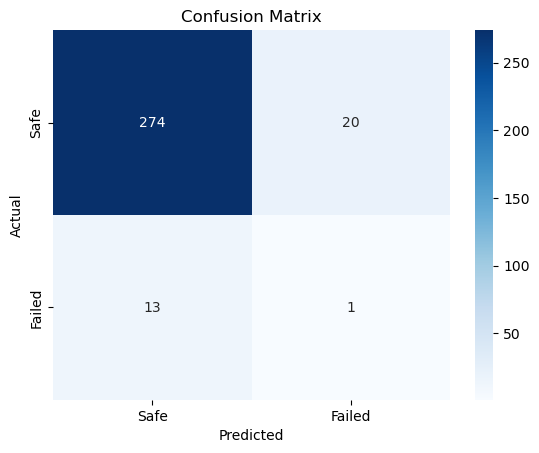

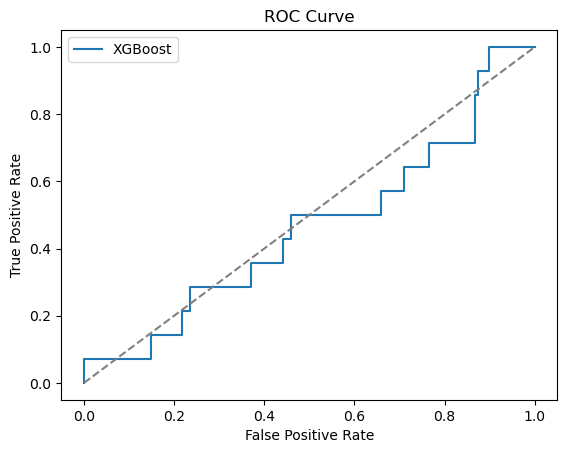

FileNotFoundError: [Errno 2] No such file or directory: 'models/trikala_model.pkl'

In [31]:
# Final Binary Classification Pipeline: Safe vs Failed

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dataset
df = pd.read_csv("trikala_india_clean.csv")

# 2. Ensure TotalFunding is numeric
df["TotalFunding"] = (
    df["TotalFunding"]
    .replace("-", "0")
    .replace(",", "", regex=True)
    .astype(float)
)

# 3. Encode categorical columns
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))

# 4. Keep only Safe (0) and Failed (1)
df_binary = df[df["StatusCode"].isin([0,1])]

X = df_binary[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df_binary["StatusCode"]

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Handle imbalance
num_safe = (y == 0).sum()
num_failed = (y == 1).sum()
scale_pos_weight = num_safe / num_failed
print("Safe:", num_safe, "Failed:", num_failed, "scale_pos_weight:", scale_pos_weight)

# 7. Train XGBoost (binary only)
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# 9. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# 10. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Safe","Failed"],
            yticklabels=["Safe","Failed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 12. Save model
joblib.dump(model, "models/trikala_model.pkl")
print("Model saved as trikala_model.pkl")


In [32]:
joblib.dump(model, "trikala_model.pkl")


['trikala_model.pkl']

Safe: 1467 Failed: 69 scale_pos_weight: 21.26086956521739
Confusion Matrix:
 [[274  20]
 [ 13   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       294
           1       0.05      0.07      0.06        14

    accuracy                           0.89       308
   macro avg       0.50      0.50      0.50       308
weighted avg       0.91      0.89      0.90       308

ROC AUC Score: 0.4630709426627793


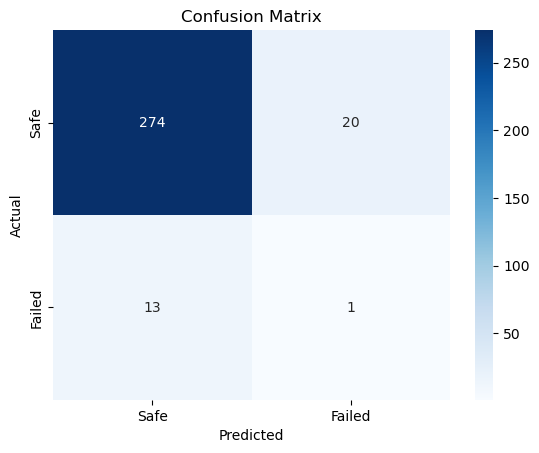

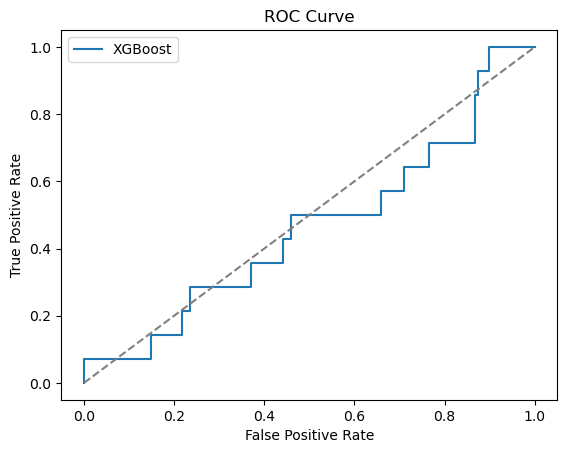

FileNotFoundError: [Errno 2] No such file or directory: 'models/trikala_model.pkl'

In [33]:
# Final Binary Classification Pipeline: Safe vs Failed

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dataset
df = pd.read_csv("trikala_india_clean.csv")

# 2. Ensure TotalFunding is numeric
df["TotalFunding"] = (
    df["TotalFunding"]
    .replace("-", "0")
    .replace(",", "", regex=True)
    .astype(float)
)

# 3. Encode categorical columns
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))

# 4. Keep only Safe (0) and Failed (1)
df_binary = df[df["StatusCode"].isin([0,1])]

X = df_binary[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df_binary["StatusCode"]

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Handle imbalance
num_safe = (y == 0).sum()
num_failed = (y == 1).sum()
scale_pos_weight = num_safe / num_failed
print("Safe:", num_safe, "Failed:", num_failed, "scale_pos_weight:", scale_pos_weight)

# 7. Train XGBoost (binary only)
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# 9. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# 10. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Safe","Failed"],
            yticklabels=["Safe","Failed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 12. Save model
joblib.dump(model, "models/trikala_model.pkl")
print("Model saved as trikala_model.pkl")


Safe: 1467 Failed: 69 scale_pos_weight: 21.26086956521739
Confusion Matrix:
 [[274  20]
 [ 13   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       294
           1       0.05      0.07      0.06        14

    accuracy                           0.89       308
   macro avg       0.50      0.50      0.50       308
weighted avg       0.91      0.89      0.90       308

ROC AUC Score: 0.4630709426627793


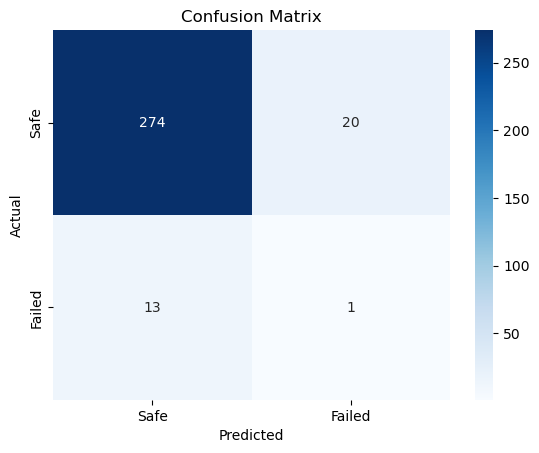

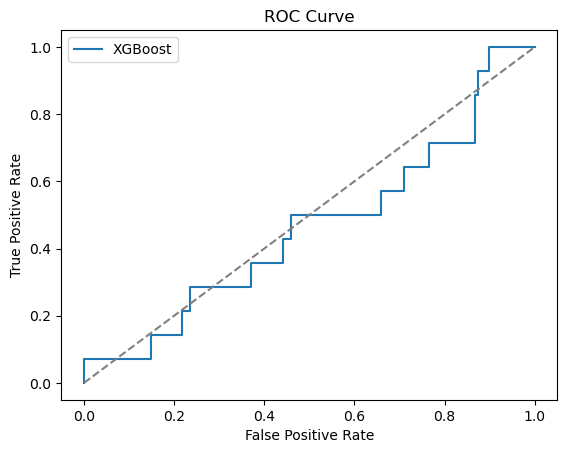

Model saved as trikala_model.pkl


In [34]:
# Final Binary Classification Pipeline: Safe vs Failed

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# 1. Load dataset
df = pd.read_csv("trikala_india_clean.csv")

# 2. Ensure TotalFunding is numeric
df["TotalFunding"] = (
    df["TotalFunding"]
    .replace("-", "0")
    .replace(",", "", regex=True)
    .astype(float)
)

# 3. Encode categorical columns
df["CityEncoded"] = LabelEncoder().fit_transform(df["City"].astype(str))
df["IndustryEncoded"] = LabelEncoder().fit_transform(df["Industry"].astype(str))

# 4. Keep only Safe (0) and Failed (1)
df_binary = df[df["StatusCode"].isin([0,1])]

X = df_binary[["TotalFunding", "FundingRounds", "CityEncoded", "IndustryEncoded"]]
y = df_binary["StatusCode"]

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Handle imbalance
num_safe = (y == 0).sum()
num_failed = (y == 1).sum()
scale_pos_weight = num_safe / num_failed
print("Safe:", num_safe, "Failed:", num_failed, "scale_pos_weight:", scale_pos_weight)

# 7. Train XGBoost (binary only)
model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# 9. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# 10. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Safe","Failed"],
            yticklabels=["Safe","Failed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 12. Save model in the same folder as notebook and CSV
joblib.dump(model, "trikala_model.pkl")
print("Model saved as trikala_model.pkl")


In [35]:
model = joblib.load("trikala_model.pkl")


In [36]:
from fastapi import FastAPI
import joblib
import pandas as pd

# Create FastAPI app
app = FastAPI()

# Load the saved model (make sure trikala_model.pkl is in the same folder)
model = joblib.load("trikala_model.pkl")

@app.post("/predict")
def predict(total_funding: float, funding_rounds: int, city_encoded: int, industry_encoded: int):
    # Prepare input as DataFrame
    data = pd.DataFrame([[total_funding, funding_rounds, city_encoded, industry_encoded]],
                        columns=["TotalFunding","FundingRounds","CityEncoded","IndustryEncoded"])
    
    # Make prediction
    prediction = model.predict(data)[0]
    
    # Return result
    return {"prediction": "Safe" if prediction == 0 else "Failed"}


ModuleNotFoundError: No module named 'fastapi'

In [ ]:
C:\Users\hp\Documents\YourProject

    